In [ ]:
## Phần kiểm tra dữ liệu đã được làm sạch chưa
# 1. Kiểm tra xem có ô dữ liệu nào bị bỏ trống không?
missing_values = df.isnull().sum()
print("Số lượng dữ liệu bị thiếu ở mỗi cột:\n", missing_values)

# 2. Kiểm tra xem có dòng nào bị trùng lặp hoàn toàn không?
duplicates = df.duplicated().sum()
print(f"\nTổng số dòng bị trùng lặp là: {duplicates}")

# 3. Xem tổng quan các kiểu dữ liệu của các cột
print("\nThông tin định dạng của bảng:")
df.info()


Số lượng dữ liệu bị thiếu ở mỗi cột:
 school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

Tổng số dòng bị trùng lặp là: 0

Thông tin định dạng của bảng:
<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null

 SỬ DỤNG LÕI THUẬT TOÁN ĐẠO HÀM GRADIENT DESCENT TỰ BULD:
 Độ chính xác mô hình: 77.93%
 Lệch chuẩn điểm số thi: 1.22 điểm


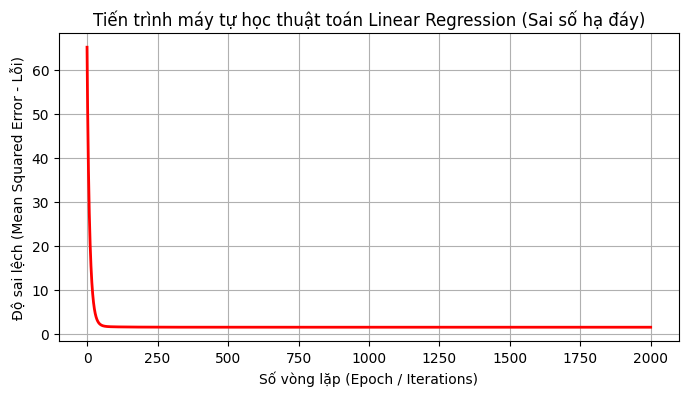

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# GIAI ĐOẠN 1: ĐỌC VÀ LÀM SẠCH DỮ LIỆU TẬN GỐC TỪ SỐ 0
# =========================================================
df = pd.read_csv("student_data.csv")

# Quét qua bảng, hễ thấy cột nào KHÔNG phải là Số là chém nó thành số nguyên
for col in df.columns:
    if not pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].astype('category').cat.codes

# [QUAN TRỌNG NHẤT]: Ép toàn bộ bảng đã dọn sạch thành Ma Trận Số Thực (Float) - Không còn một chữ nào sống sót!
df = df.astype(float)

X = df.drop('G3', axis=1) 
y = df['G3']              

X_arr = X.values 
y_arr = y.values

# Tự viết thuật toán chia Train - Test (Tỷ lệ 80% học - 20% thi)
np.random.seed(42) 
indices = np.random.permutation(len(X_arr))
train_size = int(0.8 * len(X_arr))

train_idx, test_idx = indices[:train_size], indices[train_size:]
X_train, X_test = X_arr[train_idx], X_arr[test_idx]
y_train, y_test = y_arr[train_idx], y_arr[test_idx]


# =========================================================
# GIAI ĐOẠN 2: CHUẨN HÓA DỮ LIỆU BẰNG CÔNG THỨC TOÁN
# =========================================================
def standardize_data(X_data, mean=None, std=None):
    if mean is None or std is None:
        mean = np.mean(X_data, axis=0) 
        std = np.std(X_data, axis=0)   
        std[std == 0] = 1e-8           
    X_scaled = (X_data - mean) / std
    return X_scaled, mean, std

X_train_scaled, x_mean, x_std = standardize_data(X_train)
X_test_scaled, _, _ = standardize_data(X_test, mean=x_mean, std=x_std)


# =========================================================
# GIAI ĐOẠN 3: LÕI THUẬT TOÁN HỒI QUY TỰ HỌC (LINEAR REGRESSION)
# =========================================================
class SinhVienLinearRegression:
    def __init__(self, learning_rate=0.01, iterations=1000):
        self.lr = learning_rate
        self.iterations = iterations
        self.weights = None 
        self.bias = None    
        self.loss_history = [] 

    def fit(self, X, y):
        m, n = X.shape
        self.weights = np.zeros(n)
        self.bias = 0
        
        for i in range(self.iterations):
            y_predicted = np.dot(X, self.weights) + self.bias
            error = y_predicted - y
            
            # Ghi lại Lỗi Bình phương trung bình (MSE)
            mse_loss = (1 / (2 * m)) * np.sum(error ** 2)
            self.loss_history.append(mse_loss)
            
            # Đạo hàm (Kỹ thuật Gradient Descent)
            dw = (1 / m) * np.dot(X.T, error)   
            db = (1 / m) * np.sum(error)        
            
            # Sửa sai
            self.weights = self.weights - self.lr * dw
            self.bias = self.bias - self.lr * db
            
    def predict(self, X):
        return np.dot(X, self.weights) + self.bias


# =========================================================
# GIAI ĐOẠN 4: IN KẾT QUẢ VÀ VẼ BIỂU ĐỒ BÁO CÁO TOÁN HỌC
# =========================================================
# Lắp mạng Bot và huấn luyện (Bot học 2000 vòng)
my_model = SinhVienLinearRegression(learning_rate=0.05, iterations=2000)
my_model.fit(X_train_scaled, y_train) 

# Làm bài thi thử
y_pred_tu_viet = my_model.predict(X_test_scaled)

ss_total = np.sum((y_test - np.mean(y_test)) ** 2) 
ss_residual = np.sum((y_test - y_pred_tu_viet) ** 2)   
r2_score_tu_viet = 1 - (ss_residual / ss_total)
mae_tu_viet = np.mean(np.abs(y_test - y_pred_tu_viet))

# IN BÁO CÁO CỰC ĐẸP
print(f"===========================================================")
print(f" SỬ DỤNG LÕI THUẬT TOÁN ĐẠO HÀM GRADIENT DESCENT TỰ BULD:")
print(f" Độ chính xác mô hình: {r2_score_tu_viet * 100:.2f}%")
print(f" Lệch chuẩn điểm số thi: {mae_tu_viet:.2f} điểm")
print(f"===========================================================")

# Vẽ Biểu đồ thuật toán
plt.figure(figsize=(8, 4))
plt.plot(my_model.loss_history, color='red', linewidth=2)
plt.title("Tiến trình máy tự học thuật toán Linear Regression (Sai số hạ đáy)")
plt.xlabel("Số vòng lặp (Epoch / Iterations)")
plt.ylabel("Độ sai lệch (Mean Squared Error - Lỗi)")
plt.grid(True)
plt.show()


In [3]:
import pickle

thung_hang_pkl = {
    "model_loi": my_model,     # Mô hình thuật toán do sinh viên tự build
    "gia_tri_mean": x_mean,    # Thông số trung bình để chuẩn hoá trên Web
    "gia_tri_std": x_std,      # Thông số độ lệch để chuẩn hoá trên Web
    "ten_cac_cot": X.columns.tolist() # Nhớ tên 32 cột để nhúng lên giao diện Web
}

with open('student_model.pkl', 'wb') as file:
    pickle.dump(thung_hang_pkl, file)

print("🎯 THÀNH CÔNG! Đã đóng gói xong nơ-ron não bộ ra file 'student_model.pkl'.")
print("Hãy nhìn sang menu cây thư mục bên trái VS Code, bạn sẽ thấy file này xuất hiện!")


🎯 THÀNH CÔNG! Đã đóng gói xong nơ-ron não bộ ra file 'student_model.pkl'.
Hãy nhìn sang menu cây thư mục bên trái VS Code, bạn sẽ thấy file này xuất hiện!
